In [9]:
import pandas as pd
import os
import re
from IPython.display import display

def analizar_categorica(variable, carpeta="../../Datos/Datos procesados"):
    """
    Calcula la frecuencia y porcentaje por AÑO y COHORTE (Total vs Oncológica) 
    para una variable categórica, exportando los resultados a CSVs separados.
    """
    print(f"Analizando variable categórica: {variable}...\n")
    
    # Crear directorios de salida
    dir_salida_total = "../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (categóricas)/Frecuencias finales (total)"
    dir_salida_onco = "../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (categóricas)/Frecuencias finales (oncológicos)"
    
    os.makedirs(dir_salida_total, exist_ok=True)
    os.makedirs(dir_salida_onco, exist_ok=True)
    
    archivos = [f"GRD_PROCESADO_{año}_DERIVADAS.csv" for año in range(2019, 2025)]
    lista_df = []
    
    # 1. Carga eficiente
    for archivo in archivos:
        ruta = os.path.join(carpeta, archivo)
        if os.path.exists(ruta):
            try:
                # Extraer año de forma segura con Regex
                año_str = re.search(r'\d{4}', archivo).group()
                df_temp = pd.read_csv(ruta, usecols=[variable, 'CATEGORIA_CANCER'], low_memory=False)
                df_temp['AÑO'] = año_str
                lista_df.append(df_temp)
            except ValueError:
                print(f"  [!] La variable '{variable}' no existe en {archivo}")
                
    if not lista_df:
        return "No se encontraron datos para analizar."
        
    df_full = pd.concat(lista_df, ignore_index=True)
    
    # Función auxiliar para generar tabla pivotada N (P%)
    def generar_tabla_anual(df_subset, nombre_cohorte):
        resultados = []
        años = sorted(df_subset['AÑO'].unique())
        
        for año in años:
            df_año = df_subset[df_subset['AÑO'] == año]
            total_año = len(df_año)
            
            if total_año == 0:
                continue
                
            conteos = df_año[variable].value_counts(dropna=False)
            porcentajes = (conteos / total_año) * 100
            
            for cat in conteos.index:
                # Formatear "N (P%)"
                n_fmt = f"{int(conteos[cat]):,}".replace(',', '.')
                p_fmt = f"{porcentajes[cat]:.2f}%"
                
                resultados.append({
                    'Categoría': cat,
                    'Año': año,
                    'Valor': f"{n_fmt} ({p_fmt})"
                })
                
        if not resultados:
            return pd.DataFrame()
            
        df_res = pd.DataFrame(resultados)
        
        # Pivotear: Filas = Categorías, Columnas = Años
        tabla_pivot = df_res.pivot(index='Categoría', columns='Año', values='Valor').fillna("0 (0.00%)")
        tabla_pivot.index.name = f"{variable}"
        
        return tabla_pivot

    # 2. Generar tablas separadas
    tabla_total = generar_tabla_anual(df_full, "Cohorte Total")
    
    df_onco = df_full[df_full['CATEGORIA_CANCER'] != 'SIN_CANCER']
    tabla_onco = generar_tabla_anual(df_onco, "Cohorte Oncológica")
    
    # 3. Mostrar Resultados
    print("=" * 80)
    print(f"DISTRIBUCIÓN: {variable.upper()} - COHORTE TOTAL")
    print("=" * 80)
    display(tabla_total)
    
    print("\n" + "=" * 80)
    print(f"DISTRIBUCIÓN: {variable.upper()} - COHORTE ONCOLÓGICA")
    print("=" * 80)
    display(tabla_onco)
    
    # 4. Exportar a CSVs separados
    ruta_csv_total = os.path.join(dir_salida_total, f"Tabla_{variable}_Total.csv")
    ruta_csv_onco = os.path.join(dir_salida_onco, f"Tabla_{variable}_Oncologica.csv")
    
    tabla_total.to_csv(ruta_csv_total, encoding='utf-8-sig')
    tabla_onco.to_csv(ruta_csv_onco, encoding='utf-8-sig')
        
    print(f"\nTabla Total exportada en: {ruta_csv_total}")
    print(f"Tabla Oncológica exportada en: {ruta_csv_onco}\n")

In [35]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

def analizar_numerica(variable, carpeta="../../Datos/Datos procesados"):
    """
    Calcula estadísticas descriptivas y genera boxplots separando por 
    Cohorte Total y Cohorte Oncológica, guardando en subcarpetas específicas.
    """
    print(f"Analizando variable numérica: {variable}...\n")
    
    # 1. Crear directorios de salida
    dir_salida_total = "../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (numéricas)/Estadísticas finales (total)"
    dir_salida_onco = "../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (numéricas)/Estadísticas finales (oncológicos)"
    
    os.makedirs(dir_salida_total, exist_ok=True)
    os.makedirs(dir_salida_onco, exist_ok=True)
    
    archivos = [f"GRD_PROCESADO_{año}_DERIVADAS.csv" for año in range(2019, 2025)]
    lista_df = []
    
    # 2. Carga eficiente (Ahora leemos también la categoría de cáncer)
    for archivo in archivos:
        ruta = os.path.join(carpeta, archivo)
        if os.path.exists(ruta):
            try:
                df_temp = pd.read_csv(ruta, usecols=[variable, 'CATEGORIA_CANCER'], low_memory=False)
                lista_df.append(df_temp)
            except ValueError:
                print(f"  [!] La variable '{variable}' no existe en {archivo}")
                
    if not lista_df:
        return "No se encontraron datos para analizar."
        
    df_full = pd.concat(lista_df, ignore_index=True)
    
    # Función auxiliar para procesar, mostrar y guardar por cohorte
    def procesar_cohorte(serie, nombre_cohorte, dir_salida):
        # Eliminar nulos solo para el cálculo
        serie_limpia = serie.dropna()
        n_total = len(serie_limpia)
        
        if n_total == 0:
            print(f"No hay datos válidos para la {nombre_cohorte}.")
            return

        # Cálculos Estadísticos
        minimo = serie_limpia.min()
        maximo = serie_limpia.max()
        media = serie_limpia.mean()
        varianza = serie_limpia.var()
        desviacion = serie_limpia.std()
        
        Q1 = serie_limpia.quantile(0.25)
        Q3 = serie_limpia.quantile(0.75)
        IQR = Q3 - Q1
        lim_inf = Q1 - 1.5 * IQR
        lim_sup = Q3 + 1.5 * IQR
        
        outliers = serie_limpia[(serie_limpia < lim_inf) | (serie_limpia > lim_sup)]
        n_outliers = len(outliers)
        pct_outliers = (n_outliers / n_total) * 100

        # Crear DataFrame de Estadísticas
        df_stats = pd.DataFrame({
            'Métrica': ['N Válidos', 'Mínimo', 'Máximo', 'Promedio', 'Desv. Estándar', 'Varianza', 'Límite Inf (IQR)', 'Límite Sup (IQR)', 'N Outliers', '% Outliers'],
            'Valor': [
                f"{n_total:,}".replace(',', '.'), 
                round(minimo, 2), round(maximo, 2), round(media, 2), round(desviacion, 2), round(varianza, 2), 
                round(lim_inf, 2), round(lim_sup, 2), 
                f"{n_outliers:,}".replace(',', '.'), f"{pct_outliers:.2f}%"
            ]
        })
        
        # Imprimir en pantalla
        print("=" * 60)
        print(f"ESTADÍSTICAS: {variable.upper()} - {nombre_cohorte.upper()}")
        print("=" * 60)
        display(df_stats)
        
        # Guardar CSV
        ruta_csv = os.path.join(dir_salida, f"Stats_{variable}_{nombre_cohorte.replace(' ', '_')}.csv")
        df_stats.to_csv(ruta_csv, index=False, encoding='utf-8-sig')
        
        # Gráfico de Caja (Sin escala logarítmica)
        plt.figure(figsize=(10, 3))
        sns.boxplot(x=serie_limpia, color='lightblue', fliersize=2)
        plt.title(f"Distribución de {variable} ({nombre_cohorte})")
        plt.xlabel(variable)
        
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.tight_layout()
        
        # Guardar Imagen y Mostrar
        ruta_img = os.path.join(dir_salida, f"Boxplot_{variable}_{nombre_cohorte.replace(' ', '_')}.png")
        plt.savefig(ruta_img, dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"Exportado en: {dir_salida}\n")

    # 3. Ejecutar para ambas cohortes
    # Cohorte Total
    procesar_cohorte(df_full[variable], "Cohorte Total", dir_salida_total)
    
    # Cohorte Oncológica
    df_onco = df_full[df_full['CATEGORIA_CANCER'] != 'SIN_CANCER']
    procesar_cohorte(df_onco[variable], "Cohorte Oncologica", dir_salida_onco)

In [10]:
analizar_categorica('CONSUMO_RECURSOS')

Analizando variable categórica: CONSUMO_RECURSOS...

DISTRIBUCIÓN: CONSUMO_RECURSOS - COHORTE TOTAL


Año,2019,2020,2021,2022,2023,2024
CONSUMO_RECURSOS,,,,,,
0,367.663 (33.05%),262.608 (34.11%),270.024 (33.36%),315.021 (33.99%),345.405 (33.51%),360.074 (33.45%)
1,371.914 (33.44%),252.715 (32.83%),271.182 (33.50%),304.380 (32.84%),343.037 (33.28%),362.459 (33.67%)
2,372.727 (33.51%),254.481 (33.06%),268.235 (33.14%),307.522 (33.18%),342.411 (33.22%),353.812 (32.87%)



DISTRIBUCIÓN: CONSUMO_RECURSOS - COHORTE ONCOLÓGICA


Año,2019,2020,2021,2022,2023,2024
CONSUMO_RECURSOS,,,,,,
0,10.017 (10.49%),4.404 (6.87%),5.930 (8.75%),7.017 (9.05%),8.988 (9.98%),10.160 (10.33%)
1,20.874 (21.86%),22.288 (34.77%),24.875 (36.71%),20.477 (26.42%),23.583 (26.18%),31.078 (31.61%)
2,64.600 (67.65%),37.415 (58.36%),36.958 (54.54%),50.016 (64.53%),57.493 (63.84%),57.069 (58.05%)



Tabla Total exportada en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (categóricas)/Frecuencias finales (total)\Tabla_CONSUMO_RECURSOS_Total.csv
Tabla Oncológica exportada en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (categóricas)/Frecuencias finales (oncológicos)\Tabla_CONSUMO_RECURSOS_Oncologica.csv



In [11]:
analizar_categorica('SEVERIDAD')

Analizando variable categórica: SEVERIDAD...

DISTRIBUCIÓN: SEVERIDAD - COHORTE TOTAL


Año,2019,2020,2021,2022,2023,2024
SEVERIDAD,,,,,,
0,194.396 (17.48%),79.286 (10.30%),100.767 (12.45%),154.691 (16.69%),193.427 (18.76%),211.972 (19.69%)
1,540.333 (48.58%),360.582 (46.84%),337.802 (41.73%),371.245 (40.05%),385.014 (37.35%),383.281 (35.61%)
2,233.748 (21.01%),173.704 (22.56%),182.703 (22.57%),211.988 (22.87%),251.238 (24.37%),266.701 (24.78%)
3,143.827 (12.93%),156.232 (20.30%),188.169 (23.25%),188.999 (20.39%),201.174 (19.52%),214.391 (19.92%)



DISTRIBUCIÓN: SEVERIDAD - COHORTE ONCOLÓGICA


Año,2019,2020,2021,2022,2023,2024
SEVERIDAD,,,,,,
0,20.338 (21.30%),3.632 (5.67%),5.671 (8.37%),7.901 (10.19%),10.211 (11.34%),11.079 (11.27%)
1,26.113 (27.35%),18.888 (29.46%),19.094 (28.18%),20.337 (26.24%),21.597 (23.98%),22.969 (23.36%)
2,29.764 (31.17%),23.492 (36.64%),23.685 (34.95%),26.578 (34.29%),31.777 (35.28%),34.336 (34.93%)
3,19.276 (20.19%),18.095 (28.23%),19.313 (28.50%),22.694 (29.28%),26.479 (29.40%),29.923 (30.44%)



Tabla Total exportada en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (categóricas)/Frecuencias finales (total)\Tabla_SEVERIDAD_Total.csv
Tabla Oncológica exportada en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (categóricas)/Frecuencias finales (oncológicos)\Tabla_SEVERIDAD_Oncologica.csv



In [12]:
analizar_categorica('MORTALIDAD')

Analizando variable categórica: MORTALIDAD...

DISTRIBUCIÓN: MORTALIDAD - COHORTE TOTAL


Año,2019,2020,2021,2022,2023,2024
MORTALIDAD,,,,,,
0,1.084.011 (97.46%),740.673 (96.22%),777.884 (96.10%),899.886 (97.08%),1.006.058 (97.59%),1.050.124 (97.56%)
1,28.293 (2.54%),29.131 (3.78%),31.557 (3.90%),27.037 (2.92%),24.795 (2.41%),26.221 (2.44%)



DISTRIBUCIÓN: MORTALIDAD - COHORTE ONCOLÓGICA


Año,2019,2020,2021,2022,2023,2024
MORTALIDAD,,,,,,
0,90.377 (94.64%),59.746 (93.20%),63.359 (93.50%),72.697 (93.79%),84.785 (94.14%),92.346 (93.94%)
1,5.114 (5.36%),4.361 (6.80%),4.404 (6.50%),4.813 (6.21%),5.279 (5.86%),5.961 (6.06%)



Tabla Total exportada en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (categóricas)/Frecuencias finales (total)\Tabla_MORTALIDAD_Total.csv
Tabla Oncológica exportada en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (categóricas)/Frecuencias finales (oncológicos)\Tabla_MORTALIDAD_Oncologica.csv



In [13]:
analizar_categorica('SEXO')

Analizando variable categórica: SEXO...

DISTRIBUCIÓN: SEXO - COHORTE TOTAL


Año,2019,2020,2021,2022,2023,2024
SEXO,,,,,,
HOMBRE,453.663 (40.79%),314.387 (40.84%),338.064 (41.77%),376.262 (40.59%),423.008 (41.03%),448.733 (41.69%)
MUJER,658.641 (59.21%),455.417 (59.16%),471.377 (58.23%),550.661 (59.41%),607.845 (58.97%),627.612 (58.31%)



DISTRIBUCIÓN: SEXO - COHORTE ONCOLÓGICA


Año,2019,2020,2021,2022,2023,2024
SEXO,,,,,,
HOMBRE,43.476 (45.53%),30.065 (46.90%),31.792 (46.92%),35.787 (46.17%),41.733 (46.34%),45.487 (46.27%)
MUJER,52.015 (54.47%),34.042 (53.10%),35.971 (53.08%),41.723 (53.83%),48.331 (53.66%),52.820 (53.73%)



Tabla Total exportada en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (categóricas)/Frecuencias finales (total)\Tabla_SEXO_Total.csv
Tabla Oncológica exportada en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (categóricas)/Frecuencias finales (oncológicos)\Tabla_SEXO_Oncologica.csv



In [14]:
analizar_categorica('ES_PUEBLO_ORIGINARIO')

Analizando variable categórica: ES_PUEBLO_ORIGINARIO...

DISTRIBUCIÓN: ES_PUEBLO_ORIGINARIO - COHORTE TOTAL


Año,2019,2020,2021,2022,2023,2024
ES_PUEBLO_ORIGINARIO,,,,,,
0,1.091.440 (98.12%),752.240 (97.72%),790.696 (97.68%),906.702 (97.82%),1.007.876 (97.77%),1.049.652 (97.52%)
1,20.864 (1.88%),17.564 (2.28%),18.745 (2.32%),20.221 (2.18%),22.977 (2.23%),26.693 (2.48%)



DISTRIBUCIÓN: ES_PUEBLO_ORIGINARIO - COHORTE ONCOLÓGICA


Año,2019,2020,2021,2022,2023,2024
ES_PUEBLO_ORIGINARIO,,,,,,
0,94.093 (98.54%),62.728 (97.85%),66.490 (98.12%),76.203 (98.31%),88.313 (98.06%),96.129 (97.78%)
1,1.398 (1.46%),1.379 (2.15%),1.273 (1.88%),1.307 (1.69%),1.751 (1.94%),2.178 (2.22%)



Tabla Total exportada en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (categóricas)/Frecuencias finales (total)\Tabla_ES_PUEBLO_ORIGINARIO_Total.csv
Tabla Oncológica exportada en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (categóricas)/Frecuencias finales (oncológicos)\Tabla_ES_PUEBLO_ORIGINARIO_Oncologica.csv



In [15]:
analizar_categorica('REGION')

Analizando variable categórica: REGION...

DISTRIBUCIÓN: REGION - COHORTE TOTAL


Año,2019,2020,2021,2022,2023,2024
REGION,,,,,,
REGION_ANTOFAGASTA,33.311 (2.99%),26.759 (3.48%),28.933 (3.57%),31.236 (3.37%),32.568 (3.16%),33.856 (3.15%)
REGION_ARAUCANIA,77.612 (6.98%),54.037 (7.02%),54.539 (6.74%),61.056 (6.59%),67.736 (6.57%),80.099 (7.44%)
REGION_ARICA_PARINACOTA,20.471 (1.84%),15.571 (2.02%),17.039 (2.11%),18.265 (1.97%),19.755 (1.92%),20.084 (1.87%)
REGION_ATACAMA,21.065 (1.89%),16.188 (2.10%),17.101 (2.11%),18.662 (2.01%),20.745 (2.01%),21.652 (2.01%)
REGION_AYSEN,10.309 (0.93%),7.750 (1.01%),7.514 (0.93%),8.692 (0.94%),10.208 (0.99%),10.515 (0.98%)
REGION_BIOBIO,109.639 (9.86%),73.039 (9.49%),78.175 (9.66%),93.463 (10.08%),111.293 (10.80%),117.999 (10.96%)
REGION_COQUIMBO,51.658 (4.64%),34.430 (4.47%),37.556 (4.64%),43.325 (4.67%),51.701 (5.02%),51.965 (4.83%)
REGION_LOS_LAGOS,63.526 (5.71%),42.744 (5.55%),43.355 (5.36%),49.200 (5.31%),55.403 (5.37%),57.856 (5.38%)
REGION_LOS_RIOS,25.120 (2.26%),16.748 (2.18%),17.094 (2.11%),19.516 (2.11%),24.128 (2.34%),23.372 (2.17%)



DISTRIBUCIÓN: REGION - COHORTE ONCOLÓGICA


Año,2019,2020,2021,2022,2023,2024
REGION,,,,,,
REGION_ANTOFAGASTA,3.309 (3.47%),2.335 (3.64%),2.177 (3.21%),2.511 (3.24%),3.063 (3.40%),3.491 (3.55%)
REGION_ARAUCANIA,5.691 (5.96%),4.516 (7.04%),4.364 (6.44%),4.598 (5.93%),5.700 (6.33%),6.759 (6.88%)
REGION_ARICA_PARINACOTA,1.764 (1.85%),1.454 (2.27%),1.376 (2.03%),1.459 (1.88%),1.761 (1.96%),1.898 (1.93%)
REGION_ATACAMA,1.397 (1.46%),1.244 (1.94%),1.137 (1.68%),1.210 (1.56%),1.366 (1.52%),1.551 (1.58%)
REGION_AYSEN,520 (0.54%),511 (0.80%),481 (0.71%),538 (0.69%),534 (0.59%),614 (0.62%)
REGION_BIOBIO,8.981 (9.41%),6.721 (10.48%),7.628 (11.26%),9.204 (11.87%),10.661 (11.84%),11.686 (11.89%)
REGION_COQUIMBO,3.475 (3.64%),2.582 (4.03%),2.982 (4.40%),3.414 (4.40%),4.157 (4.62%),4.455 (4.53%)
REGION_LOS_LAGOS,5.524 (5.78%),3.755 (5.86%),3.713 (5.48%),3.655 (4.72%),4.493 (4.99%),4.956 (5.04%)
REGION_LOS_RIOS,2.392 (2.50%),2.011 (3.14%),1.948 (2.87%),1.924 (2.48%),2.316 (2.57%),2.307 (2.35%)



Tabla Total exportada en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (categóricas)/Frecuencias finales (total)\Tabla_REGION_Total.csv
Tabla Oncológica exportada en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (categóricas)/Frecuencias finales (oncológicos)\Tabla_REGION_Oncologica.csv



In [16]:
analizar_categorica('ES_EXTRANJERO')

Analizando variable categórica: ES_EXTRANJERO...

DISTRIBUCIÓN: ES_EXTRANJERO - COHORTE TOTAL


Año,2019,2020,2021,2022,2023,2024
ES_EXTRANJERO,,,,,,
0,1.068.280 (96.04%),730.504 (94.89%),761.822 (94.12%),866.917 (93.53%),966.969 (93.80%),1.010.448 (93.88%)
1,44.024 (3.96%),39.300 (5.11%),47.619 (5.88%),60.006 (6.47%),63.884 (6.20%),65.897 (6.12%)



DISTRIBUCIÓN: ES_EXTRANJERO - COHORTE ONCOLÓGICA


Año,2019,2020,2021,2022,2023,2024
ES_EXTRANJERO,,,,,,
0,94.011 (98.45%),62.661 (97.74%),65.939 (97.31%),75.164 (96.97%),86.944 (96.54%),94.658 (96.29%)
1,1.480 (1.55%),1.446 (2.26%),1.824 (2.69%),2.346 (3.03%),3.120 (3.46%),3.649 (3.71%)



Tabla Total exportada en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (categóricas)/Frecuencias finales (total)\Tabla_ES_EXTRANJERO_Total.csv
Tabla Oncológica exportada en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (categóricas)/Frecuencias finales (oncológicos)\Tabla_ES_EXTRANJERO_Oncologica.csv



In [17]:
analizar_categorica('TIPO_PREVISION')

Analizando variable categórica: TIPO_PREVISION...

DISTRIBUCIÓN: TIPO_PREVISION - COHORTE TOTAL


Año,2019,2020,2021,2022,2023,2024
TIPO_PREVISION,,,,,,
FFAA_Y_ORDEN,3.917 (0.35%),3.323 (0.43%),3.388 (0.42%),3.451 (0.37%),3.628 (0.35%),3.881 (0.36%)
FONASA_A,298.501 (26.84%),195.832 (25.44%),193.615 (23.92%),215.814 (23.28%),226.928 (22.01%),223.560 (20.77%)
FONASA_B,488.955 (43.96%),348.966 (45.33%),378.393 (46.75%),446.591 (48.18%),502.133 (48.71%),534.727 (49.68%)
FONASA_C,130.564 (11.74%),94.093 (12.22%),99.641 (12.31%),111.453 (12.02%),131.886 (12.79%),140.970 (13.10%)
FONASA_D,164.302 (14.77%),113.455 (14.74%),120.858 (14.93%),134.755 (14.54%),154.867 (15.02%),164.114 (15.25%)
PRIVADO,26.065 (2.34%),14.135 (1.84%),13.546 (1.67%),14.859 (1.60%),11.411 (1.11%),9.093 (0.84%)



DISTRIBUCIÓN: TIPO_PREVISION - COHORTE ONCOLÓGICA


Año,2019,2020,2021,2022,2023,2024
TIPO_PREVISION,,,,,,
FFAA_Y_ORDEN,208 (0.22%),237 (0.37%),195 (0.29%),206 (0.27%),233 (0.26%),240 (0.24%)
FONASA_A,17.714 (18.55%),11.662 (18.19%),11.304 (16.68%),12.232 (15.78%),12.842 (14.26%),12.316 (12.53%)
FONASA_B,50.789 (53.19%),35.552 (55.46%),38.224 (56.41%),45.545 (58.76%),53.437 (59.33%),59.005 (60.02%)
FONASA_C,10.749 (11.26%),6.868 (10.71%),7.877 (11.62%),8.402 (10.84%),10.469 (11.62%),12.210 (12.42%)
FONASA_D,15.463 (16.19%),9.412 (14.68%),9.827 (14.50%),10.738 (13.85%),12.739 (14.14%),14.222 (14.47%)
PRIVADO,568 (0.59%),376 (0.59%),336 (0.50%),387 (0.50%),344 (0.38%),314 (0.32%)



Tabla Total exportada en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (categóricas)/Frecuencias finales (total)\Tabla_TIPO_PREVISION_Total.csv
Tabla Oncológica exportada en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (categóricas)/Frecuencias finales (oncológicos)\Tabla_TIPO_PREVISION_Oncologica.csv



In [18]:
analizar_categorica('TIPO_SERVICIO_SALUD')

Analizando variable categórica: TIPO_SERVICIO_SALUD...

DISTRIBUCIÓN: TIPO_SERVICIO_SALUD - COHORTE TOTAL


Año,2019,2020,2021,2022,2023,2024
TIPO_SERVICIO_SALUD,,,,,,
MACROZONA_CENTRO,243.626 (21.90%),157.506 (20.46%),164.954 (20.38%),193.140 (20.84%),219.112 (21.26%),234.851 (21.82%)
MACROZONA_CENTRO_SUR,214.947 (19.32%),151.593 (19.69%),159.157 (19.66%),185.932 (20.06%),213.000 (20.66%),233.738 (21.72%)
MACROZONA_NORTE,149.594 (13.45%),110.610 (14.37%),119.118 (14.72%),131.561 (14.19%),146.148 (14.18%),148.679 (13.81%)
MACROZONA_RM,391.347 (35.18%),273.618 (35.54%),287.128 (35.47%),326.625 (35.24%),348.939 (33.85%),353.196 (32.81%)
MACROZONA_SUR_AUSTRAL,112.790 (10.14%),76.477 (9.93%),79.084 (9.77%),89.665 (9.67%),103.654 (10.06%),105.881 (9.84%)



DISTRIBUCIÓN: TIPO_SERVICIO_SALUD - COHORTE ONCOLÓGICA


Año,2019,2020,2021,2022,2023,2024
TIPO_SERVICIO_SALUD,,,,,,
MACROZONA_CENTRO,23.522 (24.63%),13.081 (20.40%),13.226 (19.52%),15.828 (20.42%),18.842 (20.92%),20.618 (20.97%)
MACROZONA_CENTRO_SUR,16.547 (17.33%),13.019 (20.31%),14.083 (20.78%),16.241 (20.95%),18.904 (20.99%),21.565 (21.94%)
MACROZONA_NORTE,11.376 (11.91%),8.861 (13.82%),8.954 (13.21%),10.037 (12.95%),11.966 (13.29%),13.398 (13.63%)
MACROZONA_RM,34.529 (36.16%),22.180 (34.60%),24.472 (36.11%),28.256 (36.45%),31.811 (35.32%),33.541 (34.12%)
MACROZONA_SUR_AUSTRAL,9.517 (9.97%),6.966 (10.87%),7.028 (10.37%),7.148 (9.22%),8.541 (9.48%),9.185 (9.34%)



Tabla Total exportada en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (categóricas)/Frecuencias finales (total)\Tabla_TIPO_SERVICIO_SALUD_Total.csv
Tabla Oncológica exportada en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (categóricas)/Frecuencias finales (oncológicos)\Tabla_TIPO_SERVICIO_SALUD_Oncologica.csv



In [19]:
analizar_categorica('TIPO_PROCEDENCIA')

Analizando variable categórica: TIPO_PROCEDENCIA...

DISTRIBUCIÓN: TIPO_PROCEDENCIA - COHORTE TOTAL


Año,2019,2020,2021,2022,2023,2024
TIPO_PROCEDENCIA,,,,,,
AMBULATORIO_APS,19.379 (1.74%),15.100 (1.96%),13.714 (1.69%),12.791 (1.38%),14.457 (1.40%),15.305 (1.42%)
AMBULATORIO_ESPECIALIDAD,406.142 (36.51%),210.973 (27.41%),234.237 (28.94%),325.435 (35.11%),383.181 (37.17%),402.958 (37.44%)
INSTITUCION_CERRADA,2.976 (0.27%),3.755 (0.49%),5.832 (0.72%),3.350 (0.36%),5.393 (0.52%),6.634 (0.62%)
TRASLADO_PRIVADO,50.367 (4.53%),27.147 (3.53%),27.765 (3.43%),33.558 (3.62%),33.969 (3.30%),34.583 (3.21%)
TRASLADO_RED_PUBLICA,80.943 (7.28%),72.743 (9.45%),74.925 (9.26%),73.580 (7.94%),82.156 (7.97%),88.607 (8.23%)
URGENCIA_DOMICILIO,514.938 (46.29%),402.810 (52.33%),406.542 (50.23%),433.350 (46.75%),460.433 (44.67%),470.820 (43.74%)
URGENCIA_RED_PRIMARIA,37.559 (3.38%),37.276 (4.84%),46.426 (5.74%),44.859 (4.84%),51.264 (4.97%),57.438 (5.34%)



DISTRIBUCIÓN: TIPO_PROCEDENCIA - COHORTE ONCOLÓGICA


Año,2019,2020,2021,2022,2023,2024
TIPO_PROCEDENCIA,,,,,,
AMBULATORIO_APS,766 (0.80%),672 (1.05%),575 (0.85%),564 (0.73%),677 (0.75%),774 (0.79%)
AMBULATORIO_ESPECIALIDAD,61.821 (64.74%),35.018 (54.62%),38.566 (56.91%),45.367 (58.53%),51.731 (57.44%),55.889 (56.85%)
INSTITUCION_CERRADA,101 (0.11%),265 (0.41%),233 (0.34%),175 (0.23%),541 (0.60%),766 (0.78%)
TRASLADO_PRIVADO,2.013 (2.11%),1.373 (2.14%),1.375 (2.03%),1.504 (1.94%),1.744 (1.94%),1.815 (1.85%)
TRASLADO_RED_PUBLICA,4.567 (4.78%),4.244 (6.62%),4.059 (5.99%),4.272 (5.51%),5.285 (5.87%),6.149 (6.25%)
URGENCIA_DOMICILIO,24.717 (25.88%),20.930 (32.65%),21.059 (31.08%),23.477 (30.29%),27.630 (30.68%),29.801 (30.31%)
URGENCIA_RED_PRIMARIA,1.506 (1.58%),1.605 (2.50%),1.896 (2.80%),2.151 (2.78%),2.456 (2.73%),3.113 (3.17%)



Tabla Total exportada en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (categóricas)/Frecuencias finales (total)\Tabla_TIPO_PROCEDENCIA_Total.csv
Tabla Oncológica exportada en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (categóricas)/Frecuencias finales (oncológicos)\Tabla_TIPO_PROCEDENCIA_Oncologica.csv



In [20]:
analizar_categorica('TIPO_INGRESO')

Analizando variable categórica: TIPO_INGRESO...

DISTRIBUCIÓN: TIPO_INGRESO - COHORTE TOTAL


Año,2019,2020,2021,2022,2023,2024
TIPO_INGRESO,,,,,,
ELECTIVO,407.752 (36.66%),198.012 (25.72%),217.086 (26.82%),306.089 (33.02%),364.067 (35.32%),385.655 (35.83%)
OBSTETRICO,177.647 (15.97%),149.128 (19.37%),138.352 (17.09%),156.860 (16.92%),154.311 (14.97%),144.556 (13.43%)
URGENCIA,526.905 (47.37%),422.664 (54.91%),454.003 (56.09%),463.974 (50.06%),512.475 (49.71%),546.134 (50.74%)



DISTRIBUCIÓN: TIPO_INGRESO - COHORTE ONCOLÓGICA


Año,2019,2020,2021,2022,2023,2024
TIPO_INGRESO,,,,,,
ELECTIVO,62.885 (65.85%),36.214 (56.49%),38.099 (56.22%),44.667 (57.63%),51.739 (57.45%),55.131 (56.08%)
OBSTETRICO,189 (0.20%),217 (0.34%),199 (0.29%),301 (0.39%),305 (0.34%),371 (0.38%)
URGENCIA,32.417 (33.95%),27.676 (43.17%),29.465 (43.48%),32.542 (41.98%),38.020 (42.21%),42.805 (43.54%)



Tabla Total exportada en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (categóricas)/Frecuencias finales (total)\Tabla_TIPO_INGRESO_Total.csv
Tabla Oncológica exportada en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (categóricas)/Frecuencias finales (oncológicos)\Tabla_TIPO_INGRESO_Oncologica.csv



In [21]:
analizar_categorica('ESPECIALIDAD_MEDICA')

Analizando variable categórica: ESPECIALIDAD_MEDICA...

DISTRIBUCIÓN: ESPECIALIDAD_MEDICA - COHORTE TOTAL


Año,2019,2020,2021,2022,2023,2024
ESPECIALIDAD_MEDICA,,,,,,
APOYO_CLINICO_DIAGNOSTICO,2.237 (0.20%),706 (0.09%),842 (0.10%),1.300 (0.14%),1.546 (0.15%),1.715 (0.16%)
CARDIOVASCULAR,22.277 (2.00%),14.959 (1.94%),19.393 (2.40%),22.163 (2.39%),24.903 (2.42%),27.123 (2.52%)
CIRUGIA_GENERAL,180.100 (16.19%),122.548 (15.92%),119.210 (14.73%),137.050 (14.79%),149.051 (14.46%),161.084 (14.97%)
CUIDADOS_CRITICOS,8.001 (0.72%),11.808 (1.53%),16.299 (2.01%),13.605 (1.47%),13.442 (1.30%),14.501 (1.35%)
DIGESTIVO,3.637 (0.33%),1.526 (0.20%),1.577 (0.19%),2.170 (0.23%),2.826 (0.27%),2.738 (0.25%)
ESPECIALIDADES_QUIRURGICAS,234.350 (21.07%),141.734 (18.41%),159.640 (19.72%),209.195 (22.57%),247.189 (23.98%),260.729 (24.22%)
GINECO_OBSTETRICIA,231.549 (20.82%),180.737 (23.48%),174.064 (21.50%),204.051 (22.01%),210.224 (20.39%),205.896 (19.13%)
HEMATOLOGIA,8.366 (0.75%),1.128 (0.15%),1.338 (0.17%),1.759 (0.19%),2.098 (0.20%),2.887 (0.27%)
MEDICINA_GENERAL,24.534 (2.21%),13.305 (1.73%),10.250 (1.27%),8.649 (0.93%),7.804 (0.76%),9.239 (0.86%)



DISTRIBUCIÓN: ESPECIALIDAD_MEDICA - COHORTE ONCOLÓGICA


Año,2019,2020,2021,2022,2023,2024
ESPECIALIDAD_MEDICA,,,,,,
APOYO_CLINICO_DIAGNOSTICO,216 (0.23%),157 (0.24%),203 (0.30%),265 (0.34%),420 (0.47%),496 (0.50%)
CARDIOVASCULAR,424 (0.44%),318 (0.50%),459 (0.68%),610 (0.79%),735 (0.82%),827 (0.84%)
CIRUGIA_GENERAL,21.711 (22.74%),16.718 (26.08%),17.513 (25.84%),19.408 (25.04%),21.416 (23.78%),22.157 (22.54%)
CUIDADOS_CRITICOS,622 (0.65%),712 (1.11%),874 (1.29%),1.083 (1.40%),1.200 (1.33%),1.394 (1.42%)
DIGESTIVO,182 (0.19%),121 (0.19%),158 (0.23%),194 (0.25%),262 (0.29%),329 (0.33%)
ESPECIALIDADES_QUIRURGICAS,14.392 (15.07%),11.120 (17.35%),14.234 (21.01%),17.799 (22.96%),21.924 (24.34%),23.601 (24.01%)
GINECO_OBSTETRICIA,6.648 (6.96%),5.519 (8.61%),6.102 (9.00%),7.275 (9.39%),8.312 (9.23%),9.001 (9.16%)
HEMATOLOGIA,7.320 (7.67%),987 (1.54%),1.197 (1.77%),1.517 (1.96%),1.816 (2.02%),2.456 (2.50%)
MEDICINA_GENERAL,2.441 (2.56%),1.357 (2.12%),989 (1.46%),696 (0.90%),618 (0.69%),829 (0.84%)



Tabla Total exportada en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (categóricas)/Frecuencias finales (total)\Tabla_ESPECIALIDAD_MEDICA_Total.csv
Tabla Oncológica exportada en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (categóricas)/Frecuencias finales (oncológicos)\Tabla_ESPECIALIDAD_MEDICA_Oncologica.csv



In [22]:
analizar_categorica('TIPO_ACTIVIDAD')

Analizando variable categórica: TIPO_ACTIVIDAD...

DISTRIBUCIÓN: TIPO_ACTIVIDAD - COHORTE TOTAL


Año,2019,2020,2021,2022,2023,2024
TIPO_ACTIVIDAD,,,,,,
AMBULATORIO_CMA,194.209 (17.46%),79.264 (10.30%),100.760 (12.45%),154.684 (16.69%),193.421 (18.76%),211.966 (19.69%)
HOSPITALIZACION_TRADICIONAL,918.095 (82.54%),690.540 (89.70%),708.681 (87.55%),772.239 (83.31%),837.432 (81.24%),864.379 (80.31%)



DISTRIBUCIÓN: TIPO_ACTIVIDAD - COHORTE ONCOLÓGICA


Año,2019,2020,2021,2022,2023,2024
TIPO_ACTIVIDAD,,,,,,
AMBULATORIO_CMA,20.334 (21.29%),3.632 (5.67%),5.671 (8.37%),7.901 (10.19%),10.211 (11.34%),11.079 (11.27%)
HOSPITALIZACION_TRADICIONAL,75.157 (78.71%),60.475 (94.33%),62.092 (91.63%),69.609 (89.81%),79.853 (88.66%),87.228 (88.73%)



Tabla Total exportada en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (categóricas)/Frecuencias finales (total)\Tabla_TIPO_ACTIVIDAD_Total.csv
Tabla Oncológica exportada en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (categóricas)/Frecuencias finales (oncológicos)\Tabla_TIPO_ACTIVIDAD_Oncologica.csv



In [23]:
analizar_categorica('SERVICIOINGRESO')

Analizando variable categórica: SERVICIOINGRESO...

DISTRIBUCIÓN: SERVICIOINGRESO - COHORTE TOTAL


Año,2019,2020,2021,2022,2023,2024
SERVICIOINGRESO,,,,,,
AREA_QUIRURGICA,392.431 (35.28%),268.609 (34.89%),299.505 (37.00%),370.129 (39.93%),437.054 (42.40%),477.629 (44.38%)
CUIDADOS_CRITICOS,185.778 (16.70%),120.712 (15.68%),130.986 (16.18%),134.340 (14.49%),148.998 (14.45%),155.409 (14.44%)
GINECO_OBSTETRICIA,220.329 (19.81%),175.521 (22.80%),167.729 (20.72%),193.571 (20.88%),195.922 (19.01%),187.785 (17.45%)
MEDICINA_INTERNA,161.122 (14.49%),121.534 (15.79%),124.801 (15.42%),121.707 (13.13%),127.313 (12.35%),135.044 (12.55%)
NEURO_PSIQUIATRIA,11.769 (1.06%),9.506 (1.23%),11.077 (1.37%),12.392 (1.34%),13.377 (1.30%),13.382 (1.24%)
ONCOLOGIA,25.600 (2.30%),7.681 (1.00%),6.335 (0.78%),6.466 (0.70%),7.308 (0.71%),7.790 (0.72%)
PEDIATRIA,115.275 (10.36%),66.241 (8.60%),69.008 (8.53%),88.318 (9.53%),100.881 (9.79%),99.306 (9.23%)



DISTRIBUCIÓN: SERVICIOINGRESO - COHORTE ONCOLÓGICA


Año,2019,2020,2021,2022,2023,2024
SERVICIOINGRESO,,,,,,
AREA_QUIRURGICA,33.147 (34.71%),27.388 (42.72%),31.655 (46.71%),36.188 (46.69%),41.799 (46.41%),45.793 (46.58%)
CUIDADOS_CRITICOS,10.283 (10.77%),6.868 (10.71%),7.128 (10.52%),9.433 (12.17%),11.880 (13.19%),13.172 (13.40%)
GINECO_OBSTETRICIA,7.157 (7.49%),5.987 (9.34%),6.998 (10.33%),7.967 (10.28%),8.887 (9.87%),9.341 (9.50%)
MEDICINA_INTERNA,17.626 (18.46%),13.829 (21.57%),12.603 (18.60%),14.717 (18.99%),17.598 (19.54%),19.683 (20.02%)
NEURO_PSIQUIATRIA,171 (0.18%),145 (0.23%),216 (0.32%),237 (0.31%),205 (0.23%),267 (0.27%)
ONCOLOGIA,24.144 (25.28%),7.234 (11.28%),5.999 (8.85%),6.103 (7.87%),6.957 (7.72%),7.392 (7.52%)
PEDIATRIA,2.963 (3.10%),2.656 (4.14%),3.164 (4.67%),2.865 (3.70%),2.738 (3.04%),2.659 (2.70%)



Tabla Total exportada en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (categóricas)/Frecuencias finales (total)\Tabla_SERVICIOINGRESO_Total.csv
Tabla Oncológica exportada en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (categóricas)/Frecuencias finales (oncológicos)\Tabla_SERVICIOINGRESO_Oncologica.csv



In [24]:
analizar_categorica('TIPO_PROCEDIMIENTO')

Analizando variable categórica: TIPO_PROCEDIMIENTO...

DISTRIBUCIÓN: TIPO_PROCEDIMIENTO - COHORTE TOTAL


Año,2019,2020,2021,2022,2023,2024
TIPO_PROCEDIMIENTO,,,,,,
IMAGENOLOGIA_Y_DIAGNOSTICO,227.088 (20.42%),169.740 (22.05%),171.796 (21.22%),186.237 (20.09%),196.484 (19.06%),213.114 (19.80%)
OBSTETRICIA_Y_PARTO,130.921 (11.77%),111.883 (14.53%),98.384 (12.15%),113.406 (12.23%),110.460 (10.72%),100.402 (9.33%)
ODONTOLOGIA_MAXILOFACIAL,11.598 (1.04%),4.938 (0.64%),5.689 (0.70%),7.147 (0.77%),8.978 (0.87%),9.811 (0.91%)
OFTALMOLOGIA,62.061 (5.58%),31.502 (4.09%),37.663 (4.65%),54.991 (5.93%),68.545 (6.65%),70.326 (6.53%)
OTORRINOLARINGOLOGIA,20.109 (1.81%),8.255 (1.07%),8.514 (1.05%),13.734 (1.48%),15.625 (1.52%),15.976 (1.48%)
PIEL_Y_MAMA,39.146 (3.52%),26.365 (3.42%),28.035 (3.46%),34.090 (3.68%),38.671 (3.75%),42.522 (3.95%)
REPRODUCTOR_FEMENINO,52.524 (4.72%),34.352 (4.46%),40.228 (4.97%),50.568 (5.46%),57.518 (5.58%),61.294 (5.69%)
REPRODUCTOR_MASCULINO,24.034 (2.16%),11.991 (1.56%),13.367 (1.65%),19.962 (2.15%),22.796 (2.21%),24.298 (2.26%)
SISTEMA_CARDIOVASCULAR,43.674 (3.93%),23.504 (3.05%),24.911 (3.08%),30.776 (3.32%),34.968 (3.39%),36.615 (3.40%)



DISTRIBUCIÓN: TIPO_PROCEDIMIENTO - COHORTE ONCOLÓGICA


Año,2019,2020,2021,2022,2023,2024
TIPO_PROCEDIMIENTO,,,,,,
IMAGENOLOGIA_Y_DIAGNOSTICO,14.839 (15.54%),11.415 (17.81%),11.590 (17.10%),13.922 (17.96%),15.677 (17.41%),17.918 (18.23%)
OBSTETRICIA_Y_PARTO,79 (0.08%),76 (0.12%),91 (0.13%),123 (0.16%),118 (0.13%),130 (0.13%)
ODONTOLOGIA_MAXILOFACIAL,504 (0.53%),360 (0.56%),362 (0.53%),405 (0.52%),456 (0.51%),528 (0.54%)
OFTALMOLOGIA,837 (0.88%),417 (0.65%),591 (0.87%),859 (1.11%),1.081 (1.20%),1.159 (1.18%)
OTORRINOLARINGOLOGIA,516 (0.54%),296 (0.46%),366 (0.54%),415 (0.54%),443 (0.49%),463 (0.47%)
PIEL_Y_MAMA,9.713 (10.17%),6.993 (10.91%),8.378 (12.36%),10.691 (13.79%),12.595 (13.98%),13.095 (13.32%)
REPRODUCTOR_FEMENINO,2.437 (2.55%),2.069 (3.23%),2.494 (3.68%),2.837 (3.66%),3.158 (3.51%),3.420 (3.48%)
REPRODUCTOR_MASCULINO,2.005 (2.10%),1.419 (2.21%),1.539 (2.27%),2.016 (2.60%),2.341 (2.60%),2.355 (2.40%)
SISTEMA_CARDIOVASCULAR,1.206 (1.26%),981 (1.53%),1.067 (1.57%),1.317 (1.70%),1.558 (1.73%),1.700 (1.73%)



Tabla Total exportada en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (categóricas)/Frecuencias finales (total)\Tabla_TIPO_PROCEDIMIENTO_Total.csv
Tabla Oncológica exportada en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (categóricas)/Frecuencias finales (oncológicos)\Tabla_TIPO_PROCEDIMIENTO_Oncologica.csv



In [25]:
analizar_categorica('CATEGORIA_CANCER')

Analizando variable categórica: CATEGORIA_CANCER...

DISTRIBUCIÓN: CATEGORIA_CANCER - COHORTE TOTAL


Año,2019,2020,2021,2022,2023,2024
CATEGORIA_CANCER,,,,,,
"C00-C14: Labio, cavidad oral y faringe",1.006 (0.09%),704 (0.09%),791 (0.10%),923 (0.10%),879 (0.09%),1.179 (0.11%)
C15-C26: Órganos digestivos,25.002 (2.25%),17.435 (2.26%),18.159 (2.24%),20.596 (2.22%),24.248 (2.35%),26.727 (2.48%)
C30-C39: Órganos respiratorios e intratorácicos,4.580 (0.41%),2.890 (0.38%),2.828 (0.35%),3.204 (0.35%),4.070 (0.39%),4.218 (0.39%)
C40-C41: Hueso y cartílago articular,1.157 (0.10%),955 (0.12%),883 (0.11%),980 (0.11%),1.052 (0.10%),1.164 (0.11%)
C43-C44: Melanoma y otras neoplasias malignas de piel,2.925 (0.26%),1.592 (0.21%),1.819 (0.22%),2.319 (0.25%),2.471 (0.24%),2.879 (0.27%)
C45-C49: Tejidos mesoteliales y tejidos blandos,995 (0.09%),651 (0.08%),798 (0.10%),855 (0.09%),1.032 (0.10%),1.205 (0.11%)
C50: Mama,13.517 (1.22%),6.705 (0.87%),7.396 (0.91%),9.654 (1.04%),11.015 (1.07%),11.206 (1.04%)
C51-C58: Órganos genitales femeninos,7.528 (0.68%),5.602 (0.73%),6.156 (0.76%),6.381 (0.69%),7.598 (0.74%),8.409 (0.78%)
C60-C63: Órganos genitales masculinos,7.187 (0.65%),4.648 (0.60%),4.865 (0.60%),6.199 (0.67%),7.152 (0.69%),7.870 (0.73%)



DISTRIBUCIÓN: CATEGORIA_CANCER - COHORTE ONCOLÓGICA


Año,2019,2020,2021,2022,2023,2024
CATEGORIA_CANCER,,,,,,
"C00-C14: Labio, cavidad oral y faringe",1.006 (1.05%),704 (1.10%),791 (1.17%),923 (1.19%),879 (0.98%),1.179 (1.20%)
C15-C26: Órganos digestivos,25.002 (26.18%),17.435 (27.20%),18.159 (26.80%),20.596 (26.57%),24.248 (26.92%),26.727 (27.19%)
C30-C39: Órganos respiratorios e intratorácicos,4.580 (4.80%),2.890 (4.51%),2.828 (4.17%),3.204 (4.13%),4.070 (4.52%),4.218 (4.29%)
C40-C41: Hueso y cartílago articular,1.157 (1.21%),955 (1.49%),883 (1.30%),980 (1.26%),1.052 (1.17%),1.164 (1.18%)
C43-C44: Melanoma y otras neoplasias malignas de piel,2.925 (3.06%),1.592 (2.48%),1.819 (2.68%),2.319 (2.99%),2.471 (2.74%),2.879 (2.93%)
C45-C49: Tejidos mesoteliales y tejidos blandos,995 (1.04%),651 (1.02%),798 (1.18%),855 (1.10%),1.032 (1.15%),1.205 (1.23%)
C50: Mama,13.517 (14.16%),6.705 (10.46%),7.396 (10.91%),9.654 (12.46%),11.015 (12.23%),11.206 (11.40%)
C51-C58: Órganos genitales femeninos,7.528 (7.88%),5.602 (8.74%),6.156 (9.08%),6.381 (8.23%),7.598 (8.44%),8.409 (8.55%)
C60-C63: Órganos genitales masculinos,7.187 (7.53%),4.648 (7.25%),4.865 (7.18%),6.199 (8.00%),7.152 (7.94%),7.870 (8.01%)



Tabla Total exportada en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (categóricas)/Frecuencias finales (total)\Tabla_CATEGORIA_CANCER_Total.csv
Tabla Oncológica exportada en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (categóricas)/Frecuencias finales (oncológicos)\Tabla_CATEGORIA_CANCER_Oncologica.csv



In [26]:
analizar_categorica('TIPO_DIAGNOSTICO_ONCO')

Analizando variable categórica: TIPO_DIAGNOSTICO_ONCO...

DISTRIBUCIÓN: TIPO_DIAGNOSTICO_ONCO - COHORTE TOTAL


Año,2019,2020,2021,2022,2023,2024
TIPO_DIAGNOSTICO_ONCO,,,,,,
PRINCIPAL,44.999 (4.05%),34.939 (4.54%),38.748 (4.79%),44.467 (4.80%),51.394 (4.99%),54.565 (5.07%)
SECUNDARIO,50.492 (4.54%),29.168 (3.79%),29.015 (3.58%),33.043 (3.56%),38.670 (3.75%),43.742 (4.06%)
SIN_CANCER,1.016.813 (91.42%),705.697 (91.67%),741.678 (91.63%),849.413 (91.64%),940.789 (91.26%),978.038 (90.87%)



DISTRIBUCIÓN: TIPO_DIAGNOSTICO_ONCO - COHORTE ONCOLÓGICA


Año,2019,2020,2021,2022,2023,2024
TIPO_DIAGNOSTICO_ONCO,,,,,,
PRINCIPAL,44.999 (47.12%),34.939 (54.50%),38.748 (57.18%),44.467 (57.37%),51.394 (57.06%),54.565 (55.50%)
SECUNDARIO,50.492 (52.88%),29.168 (45.50%),29.015 (42.82%),33.043 (42.63%),38.670 (42.94%),43.742 (44.50%)



Tabla Total exportada en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (categóricas)/Frecuencias finales (total)\Tabla_TIPO_DIAGNOSTICO_ONCO_Total.csv
Tabla Oncológica exportada en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (categóricas)/Frecuencias finales (oncológicos)\Tabla_TIPO_DIAGNOSTICO_ONCO_Oncologica.csv



In [27]:
analizar_categorica('COMORBILIDAD_PRINCIPAL')

Analizando variable categórica: COMORBILIDAD_PRINCIPAL...

DISTRIBUCIÓN: COMORBILIDAD_PRINCIPAL - COHORTE TOTAL


Año,2019,2020,2021,2022,2023,2024
COMORBILIDAD_PRINCIPAL,,,,,,
CODIGOS PROVISIONALES (COVID),49 (0.00%),1.386 (0.18%),1.748 (0.22%),1.608 (0.17%),584 (0.06%),371 (0.03%)
ENDOCRINAS Y METABOLICAS,8.390 (0.75%),5.391 (0.70%),6.470 (0.80%),7.555 (0.82%),8.911 (0.86%),9.821 (0.91%)
INFECCIOSAS Y PARASITARIAS,2.260 (0.20%),1.754 (0.23%),1.757 (0.22%),1.971 (0.21%),2.418 (0.23%),2.673 (0.25%)
MATERNO-INFANTILES Y CONGENITAS,571 (0.05%),475 (0.06%),377 (0.05%),516 (0.06%),579 (0.06%),575 (0.05%)
NO_APLICA,1.016.813 (91.42%),705.697 (91.67%),741.678 (91.63%),849.413 (91.64%),940.789 (91.26%),978.038 (90.87%)
OJO Y OIDO,1.064 (0.10%),540 (0.07%),655 (0.08%),1.033 (0.11%),1.292 (0.13%),1.323 (0.12%)
PIEL Y TEJIDO SUBCUTANEO,905 (0.08%),644 (0.08%),659 (0.08%),714 (0.08%),878 (0.09%),1.092 (0.10%)
SANGRE E INMUNIDAD,5.889 (0.53%),4.448 (0.58%),4.262 (0.53%),4.705 (0.51%),5.558 (0.54%),6.326 (0.59%)
SINTOMAS Y HALLAZGOS,2.864 (0.26%),2.332 (0.30%),2.543 (0.31%),2.788 (0.30%),3.261 (0.32%),3.690 (0.34%)



DISTRIBUCIÓN: COMORBILIDAD_PRINCIPAL - COHORTE ONCOLÓGICA


Año,2019,2020,2021,2022,2023,2024
COMORBILIDAD_PRINCIPAL,,,,,,
CODIGOS PROVISIONALES (COVID),49 (0.05%),1.386 (2.16%),1.748 (2.58%),1.608 (2.07%),584 (0.65%),371 (0.38%)
ENDOCRINAS Y METABOLICAS,8.390 (8.79%),5.391 (8.41%),6.470 (9.55%),7.555 (9.75%),8.911 (9.89%),9.821 (9.99%)
INFECCIOSAS Y PARASITARIAS,2.260 (2.37%),1.754 (2.74%),1.757 (2.59%),1.971 (2.54%),2.418 (2.68%),2.673 (2.72%)
MATERNO-INFANTILES Y CONGENITAS,571 (0.60%),475 (0.74%),377 (0.56%),516 (0.67%),579 (0.64%),575 (0.58%)
OJO Y OIDO,1.064 (1.11%),540 (0.84%),655 (0.97%),1.033 (1.33%),1.292 (1.43%),1.323 (1.35%)
PIEL Y TEJIDO SUBCUTANEO,905 (0.95%),644 (1.00%),659 (0.97%),714 (0.92%),878 (0.97%),1.092 (1.11%)
SANGRE E INMUNIDAD,5.889 (6.17%),4.448 (6.94%),4.262 (6.29%),4.705 (6.07%),5.558 (6.17%),6.326 (6.43%)
SINTOMAS Y HALLAZGOS,2.864 (3.00%),2.332 (3.64%),2.543 (3.75%),2.788 (3.60%),3.261 (3.62%),3.690 (3.75%)
SIN_COMORBILIDAD,25.029 (26.21%),12.184 (19.01%),11.785 (17.39%),12.437 (16.05%),13.578 (15.08%),12.913 (13.14%)



Tabla Total exportada en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (categóricas)/Frecuencias finales (total)\Tabla_COMORBILIDAD_PRINCIPAL_Total.csv
Tabla Oncológica exportada en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (categóricas)/Frecuencias finales (oncológicos)\Tabla_COMORBILIDAD_PRINCIPAL_Oncologica.csv



In [28]:
analizar_categorica('ES_QUIRURGICO')

Analizando variable categórica: ES_QUIRURGICO...

DISTRIBUCIÓN: ES_QUIRURGICO - COHORTE TOTAL


Año,2019,2020,2021,2022,2023,2024
ES_QUIRURGICO,,,,,,
0,447.885 (40.27%),315.773 (41.02%),337.116 (41.65%),348.658 (37.61%),386.489 (37.49%),412.529 (38.33%)
1,664.419 (59.73%),454.031 (58.98%),472.325 (58.35%),578.265 (62.39%),644.364 (62.51%),663.816 (61.67%)



DISTRIBUCIÓN: ES_QUIRURGICO - COHORTE ONCOLÓGICA


Año,2019,2020,2021,2022,2023,2024
ES_QUIRURGICO,,,,,,
0,53.249 (55.76%),30.373 (47.38%),29.187 (43.07%),32.552 (42.00%),37.721 (41.88%),42.879 (43.62%)
1,42.242 (44.24%),33.734 (52.62%),38.576 (56.93%),44.958 (58.00%),52.343 (58.12%),55.428 (56.38%)



Tabla Total exportada en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (categóricas)/Frecuencias finales (total)\Tabla_ES_QUIRURGICO_Total.csv
Tabla Oncológica exportada en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (categóricas)/Frecuencias finales (oncológicos)\Tabla_ES_QUIRURGICO_Oncologica.csv



numericas

Analizando variable numérica: NUM_COMORBILIDADES...

ESTADÍSTICAS: NUM_COMORBILIDADES - COHORTE TOTAL


,Métrica,Valor
0,N Válidos,5.725.670
1,Mínimo,0
2,Máximo,35
3,Promedio,3.95
4,Desv. Estándar,3.5
5,Varianza,12.22
6,Límite Inf (IQR),-5.0
7,Límite Sup (IQR),11.0
8,N Outliers,232.621
9,% Outliers,4.06%


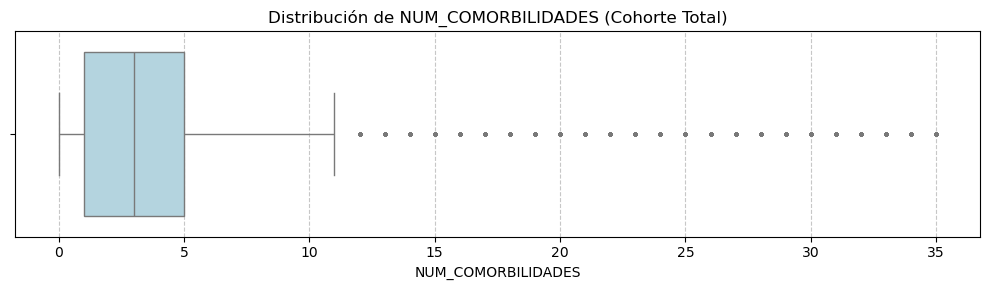

Exportado en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (numéricas)/Estadísticas finales (total)

ESTADÍSTICAS: NUM_COMORBILIDADES - COHORTE ONCOLOGICA


,Métrica,Valor
0,N Válidos,493.242
1,Mínimo,0
2,Máximo,34
3,Promedio,3.72
4,Desv. Estándar,3.85
5,Varianza,14.81
6,Límite Inf (IQR),-5.0
7,Límite Sup (IQR),11.0
8,N Outliers,23.560
9,% Outliers,4.78%


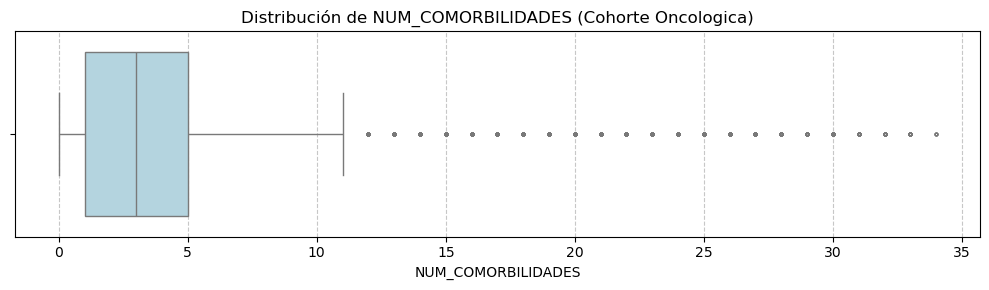

Exportado en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (numéricas)/Estadísticas finales (oncológicos)



In [36]:
analizar_numerica('NUM_COMORBILIDADES')

Analizando variable numérica: CARGA_ONCOLOGICA...

ESTADÍSTICAS: CARGA_ONCOLOGICA - COHORTE TOTAL


,Métrica,Valor
0,N Válidos,5.725.670
1,Mínimo,0
2,Máximo,11
3,Promedio,0.16
4,Desv. Estándar,0.47
5,Varianza,0.22
6,Límite Inf (IQR),0.0
7,Límite Sup (IQR),0.0
8,N Outliers,714.448
9,% Outliers,12.48%


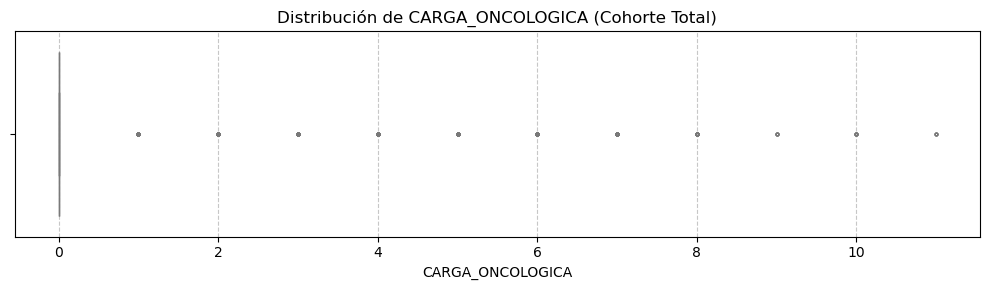

Exportado en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (numéricas)/Estadísticas finales (total)

ESTADÍSTICAS: CARGA_ONCOLOGICA - COHORTE ONCOLOGICA


,Métrica,Valor
0,N Válidos,493.242
1,Mínimo,1
2,Máximo,11
3,Promedio,1.35
4,Desv. Estándar,0.71
5,Varianza,0.51
6,Límite Inf (IQR),1.0
7,Límite Sup (IQR),1.0
8,N Outliers,120.640
9,% Outliers,24.46%


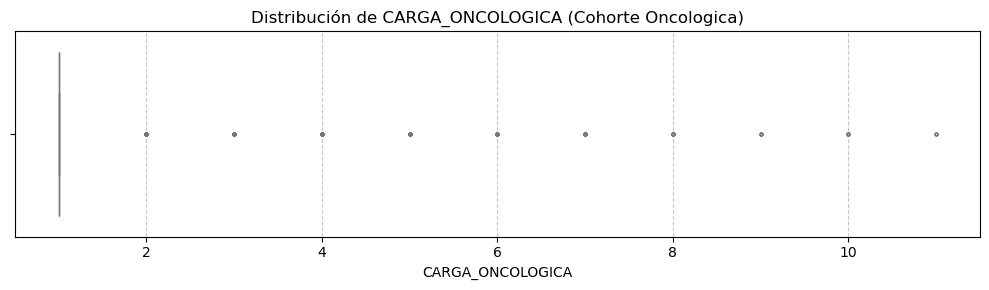

Exportado en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (numéricas)/Estadísticas finales (oncológicos)



In [37]:
analizar_numerica('CARGA_ONCOLOGICA')

Analizando variable numérica: NUM_PROCEDIMIENTOS...

ESTADÍSTICAS: NUM_PROCEDIMIENTOS - COHORTE TOTAL


,Métrica,Valor
0,N Válidos,5.725.670
1,Mínimo,1
2,Máximo,30
3,Promedio,8.05
4,Desv. Estándar,6.03
5,Varianza,36.36
6,Límite Inf (IQR),-6.5
7,Límite Sup (IQR),21.5
8,N Outliers,243.710
9,% Outliers,4.26%


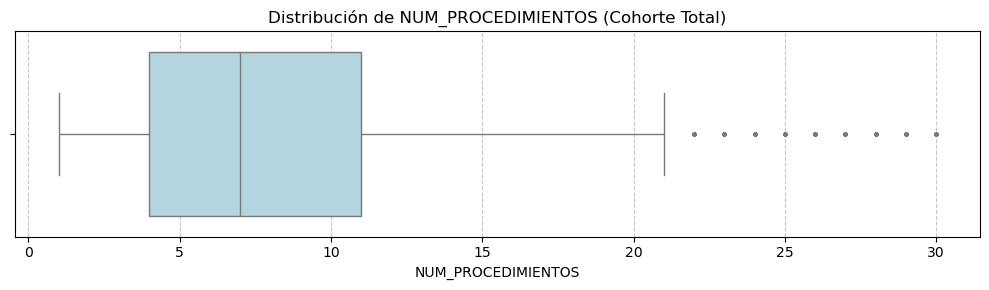

Exportado en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (numéricas)/Estadísticas finales (total)

ESTADÍSTICAS: NUM_PROCEDIMIENTOS - COHORTE ONCOLOGICA


,Métrica,Valor
0,N Válidos,493.242
1,Mínimo,1
2,Máximo,30
3,Promedio,8.67
4,Desv. Estándar,6.8
5,Varianza,46.29
6,Límite Inf (IQR),-8.0
7,Límite Sup (IQR),24.0
8,N Outliers,20.405
9,% Outliers,4.14%


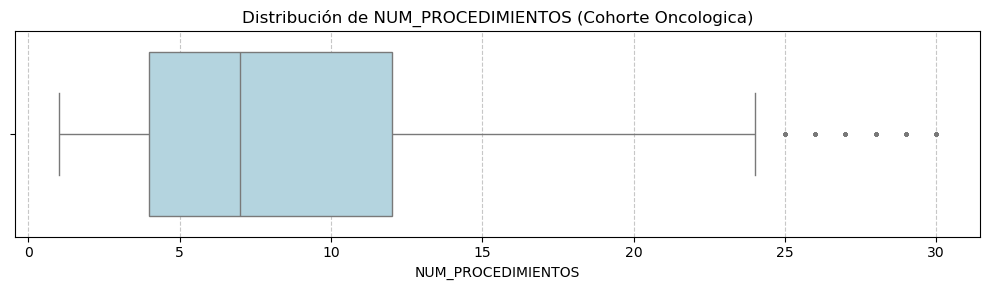

Exportado en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (numéricas)/Estadísticas finales (oncológicos)



In [38]:
analizar_numerica('NUM_PROCEDIMIENTOS')

Analizando variable numérica: CANTIDAD_TRASLADOS...

ESTADÍSTICAS: CANTIDAD_TRASLADOS - COHORTE TOTAL


,Métrica,Valor
0,N Válidos,5.725.670
1,Mínimo,0
2,Máximo,9
3,Promedio,0.26
4,Desv. Estándar,0.68
5,Varianza,0.46
6,Límite Inf (IQR),0.0
7,Límite Sup (IQR),0.0
8,N Outliers,988.796
9,% Outliers,17.27%


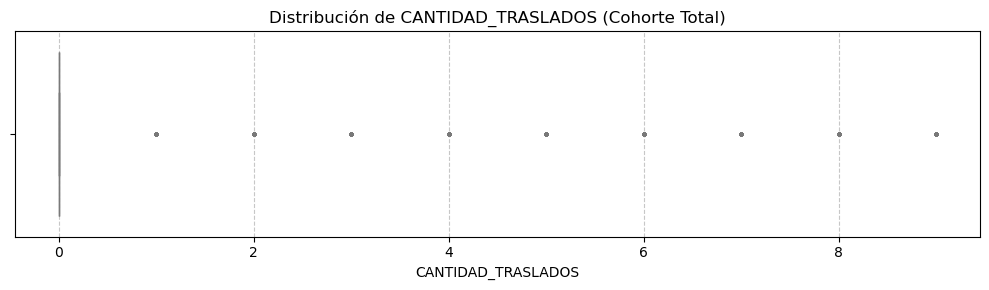

Exportado en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (numéricas)/Estadísticas finales (total)

ESTADÍSTICAS: CANTIDAD_TRASLADOS - COHORTE ONCOLOGICA


,Métrica,Valor
0,N Válidos,493.242
1,Mínimo,0
2,Máximo,9
3,Promedio,0.3
4,Desv. Estándar,0.79
5,Varianza,0.62
6,Límite Inf (IQR),0.0
7,Límite Sup (IQR),0.0
8,N Outliers,86.810
9,% Outliers,17.60%


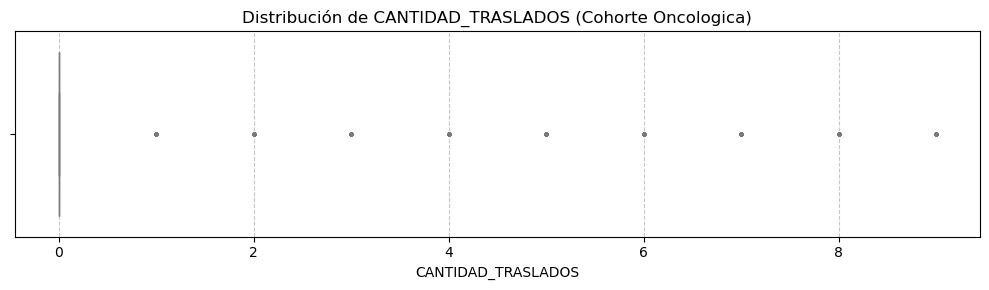

Exportado en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (numéricas)/Estadísticas finales (oncológicos)



In [39]:
analizar_numerica('CANTIDAD_TRASLADOS')

Analizando variable numérica: EDAD...

ESTADÍSTICAS: EDAD - COHORTE TOTAL


,Métrica,Valor
0,N Válidos,5.725.670
1,Mínimo,0.0
2,Máximo,124.0
3,Promedio,44.26
4,Desv. Estándar,25.4
5,Varianza,645.03
6,Límite Inf (IQR),-36.5
7,Límite Sup (IQR),127.5
8,N Outliers,0
9,% Outliers,0.00%


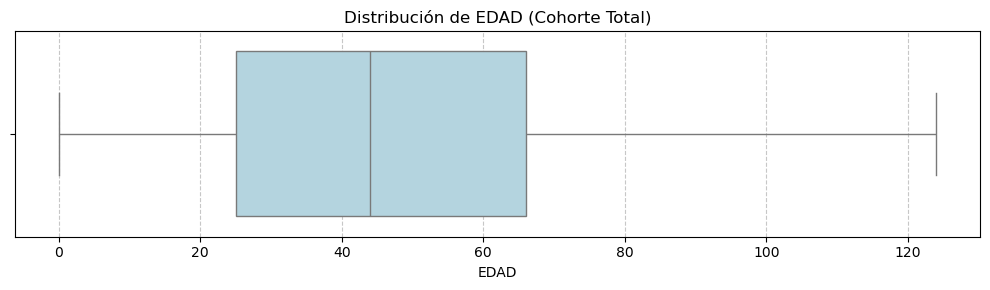

Exportado en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (numéricas)/Estadísticas finales (total)

ESTADÍSTICAS: EDAD - COHORTE ONCOLOGICA


,Métrica,Valor
0,N Válidos,493.242
1,Mínimo,0.0
2,Máximo,118.0
3,Promedio,57.63
4,Desv. Estándar,20.94
5,Varianza,438.61
6,Límite Inf (IQR),12.0
7,Límite Sup (IQR),108.0
8,N Outliers,28.049
9,% Outliers,5.69%


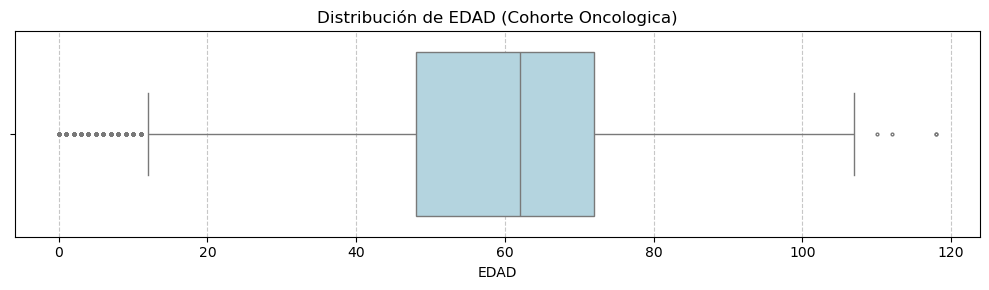

Exportado en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (numéricas)/Estadísticas finales (oncológicos)



In [40]:
analizar_numerica('EDAD')

Analizando variable numérica: DIAS_ESTADIA...

ESTADÍSTICAS: DIAS_ESTADIA - COHORTE TOTAL


,Métrica,Valor
0,N Válidos,5.725.670
1,Mínimo,0.0
2,Máximo,3433.0
3,Promedio,5.97
4,Desv. Estándar,13.72
5,Varianza,188.14
6,Límite Inf (IQR),-6.5
7,Límite Sup (IQR),13.5
8,N Outliers,606.511
9,% Outliers,10.59%


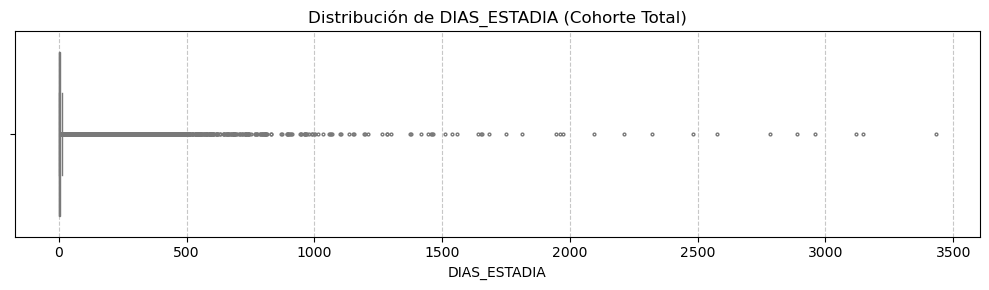

Exportado en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (numéricas)/Estadísticas finales (total)

ESTADÍSTICAS: DIAS_ESTADIA - COHORTE ONCOLOGICA


,Métrica,Valor
0,N Válidos,493.242
1,Mínimo,0.0
2,Máximo,806.0
3,Promedio,7.55
4,Desv. Estándar,12.77
5,Varianza,163.08
6,Límite Inf (IQR),-11.0
7,Límite Sup (IQR),21.0
8,N Outliers,40.002
9,% Outliers,8.11%


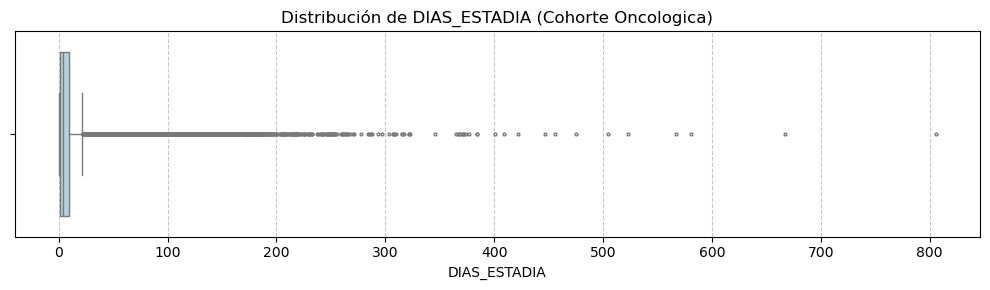

Exportado en: ../../Resultados/Resultados (etapa 1 y 2)/Análisis final/Análisis final (numéricas)/Estadísticas finales (oncológicos)



In [41]:
analizar_numerica('DIAS_ESTADIA')

In [ ]:
import pandas as pd
import os
from IPython.display import display

# 1. Definir rutas
carpeta_procesados = "../../Datos/Datos procesados"
archivos_derivadas = [f"GRD_PROCESADO_{año}_DERIVADAS.csv" for año in range(2019, 2025)]

vars_num = [
    'CANTIDAD_TRASLADOS', 'CARGA_ONCOLOGICA', 'NUM_COMORBILIDADES', 
    'NUM_PROCEDIMIENTOS', 'EDAD', 'DIAS_ESTADIA'
]

print("Leyendo y calculando nulos... por favor espera.\n")

resultados_nulos = []
totales_anuales = {}

for archivo in archivos_derivadas:
    ruta = os.path.join(carpeta_procesados, archivo)
    if not os.path.exists(ruta):
        continue
        
    año = archivo[-17:-13]
    df = pd.read_csv(ruta, usecols=vars_num, low_memory=False)
    
    total_filas = len(df)
    totales_anuales[año] = total_filas
    nulos = df.isna().sum()
    
    for var in vars_num:
        cant_nulos = nulos[var]
        pct_nulos = (cant_nulos / total_filas) * 100
        
        # Formatear como "N (P%)"
        texto_nulos = f"{cant_nulos} ({pct_nulos:.3f}%)" if cant_nulos > 0 else "0"
        
        resultados_nulos.append({
            'Año': año,
            'Variable': var,
            'Nulos_Formateados': texto_nulos
        })

# Crear DataFrame y pivotear
if resultados_nulos:
    df_nulos = pd.DataFrame(resultados_nulos)
    tabla_final = df_nulos.pivot(index='Variable', columns='Año', values='Nulos_Formateados')
    
    # Imprimir un resumen de los totales de egresos primero
    print("=== TOTAL DE EGRESOS POR AÑO ===")
    for anio, total in totales_anuales.items():
        print(f"{anio}: {total:,}".replace(',', '.'))
        
    print("\n=== RECUENTO DE NULOS (NaN) EN VARIABLES DERIVADAS ===")
    display(tabla_final)
else:
    print("No se encontraron archivos procesados para analizar.")

Leyendo y calculando nulos... por favor espera.

=== TOTAL DE EGRESOS POR AÑO ===
019_: 1.112.304
020_: 769.815
021_: 809.441
022_: 926.931
023_: 1.030.863
024_: 1.076.398

=== RECUENTO DE NULOS (NaN) EN VARIABLES DERIVADAS ===


Año,019_,020_,021_,022_,023_,024_
Variable,,,,,,
CANTIDAD_TRASLADOS,0,0,0,0,0,0
CARGA_ONCOLOGICA,0,0,0,0,0,0
DIAS_ESTADIA,0,10 (0.001%),0,1 (0.000%),0,50 (0.005%)
EDAD,0,1 (0.000%),0,7 (0.001%),10 (0.001%),53 (0.005%)
NUM_COMORBILIDADES,0,0,0,0,0,0
NUM_PROCEDIMIENTOS,0,0,0,0,0,0
